# Análise Preditiva de Doenças Neonatais (Machine Learning)

Este notebook tem como objetivo construir um modelo preditivo para identificar o risco de um recém-nascido ser diagnosticado com uma doença e encaminhado ao programa de tratamento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

## 1. Carregamento dos Dados

In [2]:
# Carregando tabelas principais
cols_pessoa = ['co_seq_pessoa', 'se_pessoa', 'dt_nascimento', 'pes_nascimento_grama', 'ida_nascimento_mes', 'ide_prematuro', 'ide_parto_gemelar', 'ide_fez_pre_natal', 'ide_mae_uso_corticoide']
df_pessoa = pd.read_csv('./datasets2/tb_pessoa.csv', usecols=cols_pessoa, low_memory=False)

cols_amostra = ['co_seq_amostra', 'co_seq_pessoa', 'dt_col_amostra', 'dt_rec_amostra']
df_amostra = pd.read_csv('./datasets1/tb_amostra.csv', usecols=cols_amostra, low_memory=False)

cols_paciente = ['co_seq_paciente', 'co_seq_pessoa']
df_paciente = pd.read_csv('./datasets2/tb_paciente.csv', usecols=cols_paciente, low_memory=False)

print(f"Pessoas: {df_pessoa.shape}")
print(f"Amostras: {df_amostra.shape}")
print(f"Pacientes (Doentes): {df_paciente.shape}")

Pessoas: (544942, 9)
Amostras: (554474, 4)
Pacientes (Doentes): (384, 2)


## 2. Engenharia de Dados (Feature Engineering)

In [3]:
# Cruzando os dados
df_merged = df_amostra.merge(df_pessoa, on='co_seq_pessoa', how='inner')

# Criando a variável alvo (Target)
pacientes_ids = set(df_paciente['co_seq_pessoa'].unique())
df_merged['target'] = df_merged['co_seq_pessoa'].apply(lambda x: 1 if x in pacientes_ids else 0)

print("Distribuição do Target:")
print(df_merged['target'].value_counts(normalize=True) * 100)

Distribuição do Target:
target
0    99.631903
1     0.368097
Name: proportion, dtype: float64


In [4]:
# Datas para datetime e extração de idade de coleta
df_merged['dt_nascimento'] = pd.to_datetime(df_merged['dt_nascimento'], format='%Y%m%d', errors='coerce')
df_merged['dt_col_amostra'] = pd.to_datetime(df_merged['dt_col_amostra'], format='%Y%m%d', errors='coerce')

# Idade em dias na coleta
df_merged['idade_coleta_dias'] = (df_merged['dt_col_amostra'] - df_merged['dt_nascimento']).dt.days

# Tratando valores negativos ou extremos (outliers)
df_merged.loc[(df_merged['idade_coleta_dias'] < 0) | (df_merged['idade_coleta_dias'] > 180), 'idade_coleta_dias'] = np.nan

# Limpando features nulas incorretas ou dados errados
features = ['se_pessoa', 'pes_nascimento_grama', 'ide_prematuro', 'ide_parto_gemelar', 'idade_coleta_dias']
df_model = df_merged[features + ['target']].copy()

# Imputação básica de nulos Numéricos
num_cols = ['pes_nascimento_grama', 'idade_coleta_dias']
imputer_num = SimpleImputer(strategy='median')
df_model[num_cols] = imputer_num.fit_transform(df_model[num_cols])

# Imputação Categórica e Tratamento
df_model['se_pessoa'] = df_model['se_pessoa'].fillna('I').apply(lambda x: x if x in ['M', 'F'] else 'I') # I para Indefinido
df_model['ide_prematuro'] = df_model['ide_prematuro'].fillna('N')
df_model['ide_parto_gemelar'] = df_model['ide_parto_gemelar'].fillna('N')

# Encode variáveis categóricas
df_model = pd.get_dummies(df_model, columns=['se_pessoa', 'ide_prematuro', 'ide_parto_gemelar'], drop_first=True)

display(df_model.head())

,pes_nascimento_grama,idade_coleta_dias,target,se_pessoa_I,se_pessoa_M,ide_prematuro_N,ide_prematuro_S,ide_parto_gemelar_N,ide_parto_gemelar_S
0,3855.0,4.0,0,True,False,True,False,True,False
1,2955.0,6.0,0,False,False,True,False,True,False
2,3610.0,12.0,0,False,True,True,False,True,False
3,3130.0,8.0,0,False,False,True,False,True,False
4,3715.0,21.0,0,False,True,True,False,True,False


## 3. Divisão Treino e Teste (com Estratificação)

In [5]:
X = df_model.drop('target', axis=1)
y = df_model['target']

# Padronização dos numéricos
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Split estratificado por causa do desbalanceamento extremo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Treino positivo: {y_train.sum()} / Treino negativo: {len(y_train) - y_train.sum()}")
print(f"Teste positivo: {y_test.sum()} / Teste negativo: {len(y_test) - y_test.sum()}")

Treino positivo: 1531 / Treino negativo: 414324
Teste positivo: 510 / Teste negativo: 138109


## 4. Modelagem e Treinamento

In [6]:
# Modelo 1: Regressão Logística (com balanceamento de classes automático)
print("Treinando Regressão Logística...")
lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)

# Previsões LR
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Modelo 2: Random Forest (com class_weight)
print("Treinando Random Forest...")
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Previsões RF
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

Treinando Regressão Logística...
Treinando Random Forest...


## 5. Avaliação

================ Regressão Logística =================
              precision    recall  f1-score   support

           0       1.00      0.89      0.94    138109
           1       0.02      0.64      0.04       510

    accuracy                           0.89    138619
   macro avg       0.51      0.76      0.49    138619
weighted avg       0.99      0.89      0.94    138619



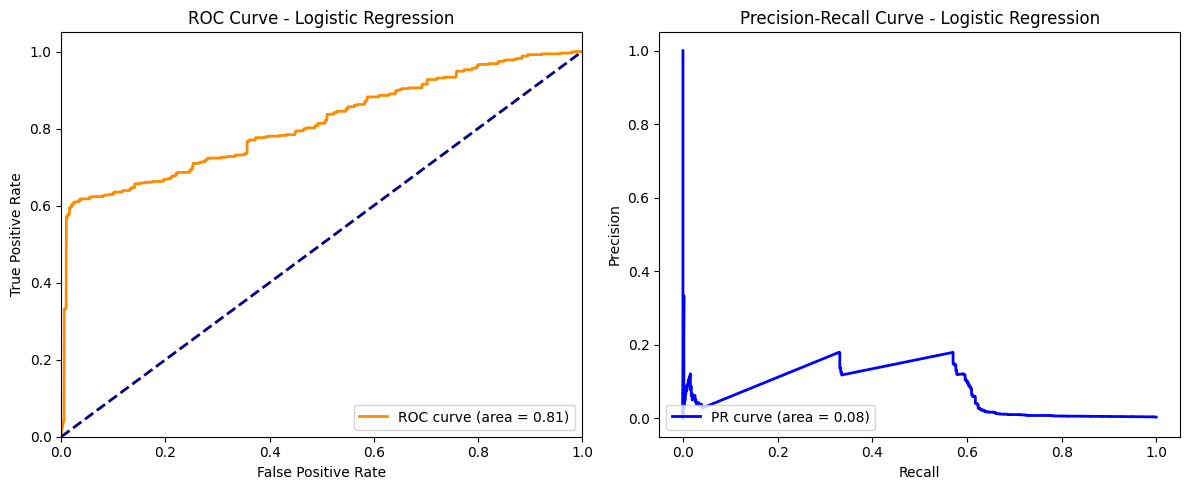


================ Random Forest =================
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    138109
           1       0.06      0.88      0.11       510

    accuracy                           0.95    138619
   macro avg       0.53      0.91      0.54    138619
weighted avg       1.00      0.95      0.97    138619



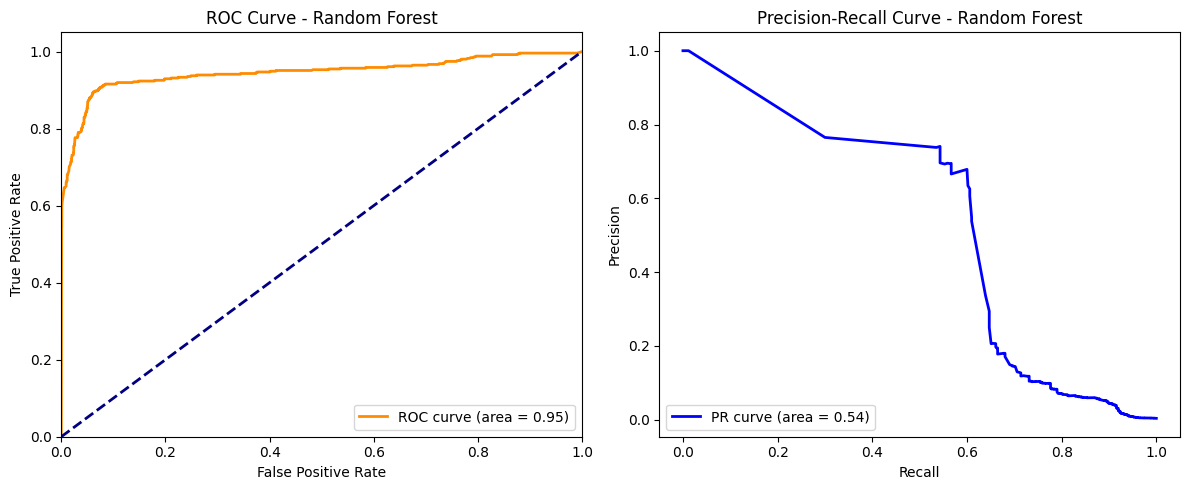

In [ ]:
def plot_roc_pr(y_true, y_prob, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    
    plt.subplot(1, 2, 2)131
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}')
    plt.legend(loc="lower left")
    
    plt.tight_layout()
    plt.show()

print("================ Regressão Logística =================")
print(classification_report(y_test, y_pred_lr))
plot_roc_pr(y_test, y_prob_lr, "Logistic Regression")

print("\n================ Random Forest =================")
print(classification_report(y_test, y_pred_rf))
plot_roc_pr(y_test, y_prob_rf, "Random Forest")


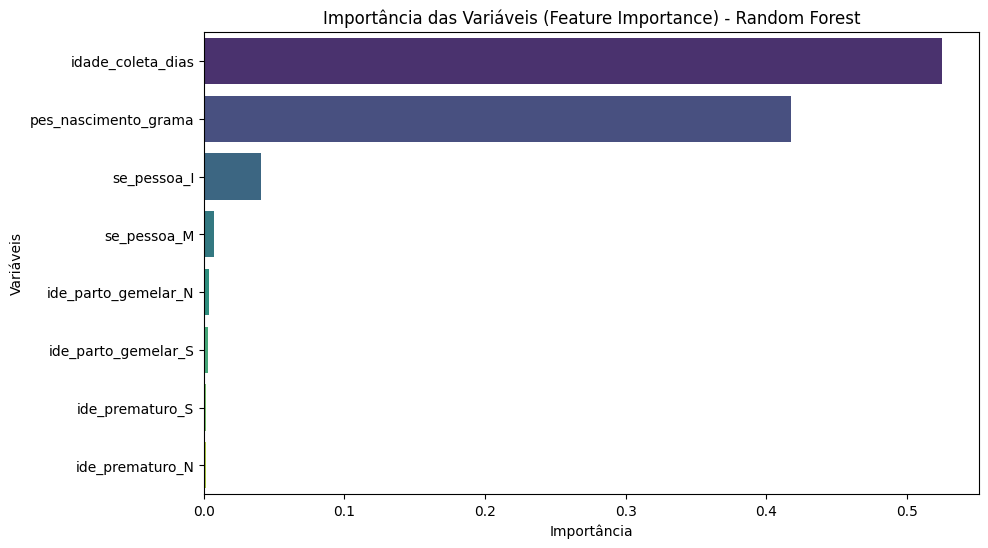

In [8]:
# Importância das features na Floresta Aleatória
feature_importances = pd.DataFrame(
    rf.feature_importances_,
    index = X_train.columns,
    columns=['importance']
).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y=feature_importances.index, data=feature_importances, palette='viridis')
plt.title('Importância das Variáveis (Feature Importance) - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variáveis')
plt.show()